In [8]:
import pandas as pd
url = "https://raw.githubusercontent.com/abescara/E-commerce-Sales-and-Customer-Analytics-Dashboard/refs/heads/main/ecommerce_master.csv"
df = pd.read_csv(url)
df.head()

,month,category,total_orders,items_sold,revenue,average_item_price
0,2019-01-01,Suits & Sport Coats,1,1,59.95,59.95
1,2019-02-01,Outerwear & Coats,1,1,71.99,71.99
2,2019-02-01,Jeans,1,1,49.50,49.50
3,2019-02-01,Sleep & Lounge,1,1,44.99,44.99
4,2019-02-01,Leggings,1,1,16.99,16.99


In [10]:
print("Rows and Columns", df.shape)
df.info()
df.isna().sum()

Rows and Columns (2175, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2175 entries, 0 to 2174
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   month               2175 non-null   object 
 1   category            2175 non-null   object 
 2   total_orders        2175 non-null   int64  
 3   items_sold          2175 non-null   int64  
 4   revenue             2175 non-null   float64
 5   average_item_price  2175 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 102.1+ KB


,0
month,0
category,0
total_orders,0
items_sold,0
revenue,0
average_item_price,0


In [11]:
df["month"] = pd.to_datetime(df["month"])

print("Date range:", df["month"].min(), "to", df["month"].max())
print("Number of categories:", df["category"].nunique())

print("\nCategories:")
print(df["category"].value_counts().head(10))

print("\nSummary statistics:")
df.describe()

Date range: 2019-01-01 00:00:00 to 2026-09-01 00:00:00
Number of categories: 26

Categories:
category
Swim                 91
Jeans                91
Tops & Tees          91
Shorts               90
Intimates            90
Outerwear & Coats    90
Accessories          89
Sleep & Lounge       89
Underwear            88
Pants                88
Name: count, dtype: int64

Summary statistics:


,month,total_orders,items_sold,revenue,average_item_price
count,2175,2175.000000,2175.000000,2175.000000,2175.000000
mean,2023-02-08 11:30:32.275862016,20.238621,20.875402,1237.285816,60.101209
min,2019-01-01 00:00:00,1.000000,1.000000,6.250000,6.250000
25%,2021-05-01 00:00:00,4.000000,4.000000,197.745000,32.930000
50%,2023-03-01 00:00:00,11.000000,12.000000,595.000000,48.900000
75%,2024-12-01 00:00:00,26.000000,27.000000,1491.855000,73.040000
max,2026-09-01 00:00:00,242.000000,253.000000,26134.210000,598.000000
std,NaN,26.029503,26.941478,1894.144130,45.658289


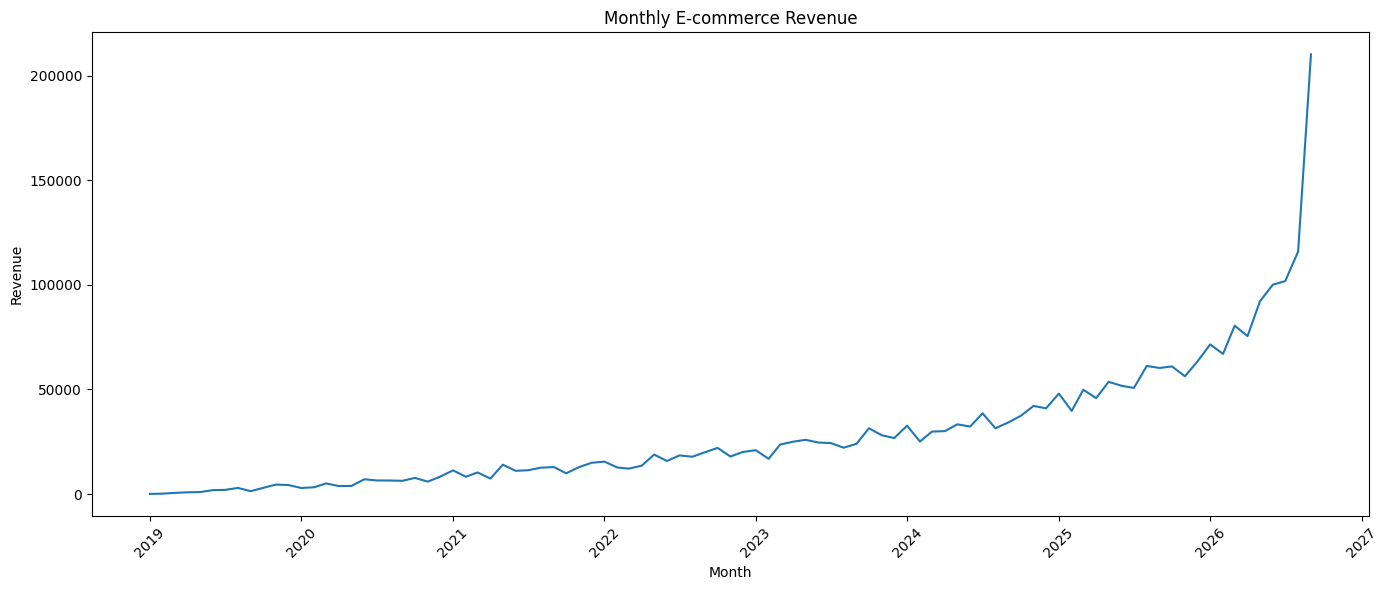

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_sales = (
    df.groupby("month", as_index=False)
      .agg(
          revenue=("revenue", "sum"),
          total_orders=("total_orders", "sum"),
          items_sold=("items_sold", "sum")
      )
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="revenue"
)

plt.title("Monthly E-commerce Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
monthly_sales["revenue_change_pct"] = (
    monthly_sales["revenue"].pct_change() * 100
)

print("Last 12 months:")
display(monthly_sales.tail(12))

print("Highest-revenue months:")
display(
    monthly_sales
    .sort_values("revenue", ascending=False)
    .head(10)
)

Last 12 months:


,month,revenue,total_orders,items_sold,revenue_change_pct
81,2025-10-01,61029.80,1038,1071,1.221378
82,2025-11-01,56317.08,878,914,-7.721998
83,2025-12-01,63338.59,1062,1094,12.467816
84,2026-01-01,71554.30,1111,1142,12.971097
85,2026-02-01,67012.68,1150,1179,-6.347096
86,2026-03-01,80538.83,1301,1337,20.184464
87,2026-04-01,75527.35,1270,1305,-6.222440
88,2026-05-01,92171.72,1538,1587,22.037540
89,2026-06-01,100114.70,1566,1617,8.617589
90,2026-07-01,101856.71,1748,1807,1.740014


Highest-revenue months:


,month,revenue,total_orders,items_sold,revenue_change_pct
92,2026-09-01,210289.22,3443,3545,81.402128
91,2026-08-01,115924.34,1877,1924,13.811196
90,2026-07-01,101856.71,1748,1807,1.740014
89,2026-06-01,100114.70,1566,1617,8.617589
88,2026-05-01,92171.72,1538,1587,22.037540
86,2026-03-01,80538.83,1301,1337,20.184464
87,2026-04-01,75527.35,1270,1305,-6.222440
84,2026-01-01,71554.30,1111,1142,12.971097
85,2026-02-01,67012.68,1150,1179,-6.347096
83,2025-12-01,63338.59,1062,1094,12.467816


In [14]:
latest_month = df["month"].max()
previous_month = latest_month - pd.DateOffset(months=1)

latest = (
    df[df["month"] == latest_month]
    .sort_values("revenue", ascending=False)
)

previous = (
    df[df["month"] == previous_month]
    .sort_values("revenue", ascending=False)
)

print("Latest month:", latest_month)
print("Previous month:", previous_month)

print("Latest month by category:")
display(
    latest[
        ["category", "revenue", "total_orders", "items_sold", "average_item_price"]
    ]
)

print("Number of categories in latest month:", latest["category"].nunique())

Latest month: 2026-09-01 00:00:00
Previous month: 2026-08-01 00:00:00
Latest month by category:


,category,revenue,total_orders,items_sold,average_item_price
2149,Outerwear & Coats,26134.21,185,187,139.76
2150,Jeans,23751.22,242,253,93.88
2151,Sweaters,15810.49,211,216,73.20
2152,Swim,13321.80,223,228,58.43
2153,Fashion Hoodies & Sweatshirts,13088.06,223,230,56.90
2154,Suits & Sport Coats,12283.66,97,99,124.08
2155,Shorts,10458.91,220,231,45.28
2156,Sleep & Lounge,10339.67,202,209,49.47
2157,Tops & Tees,10117.56,235,242,41.81
2158,Dresses,9432.85,109,111,84.98


Number of categories in latest month: 26


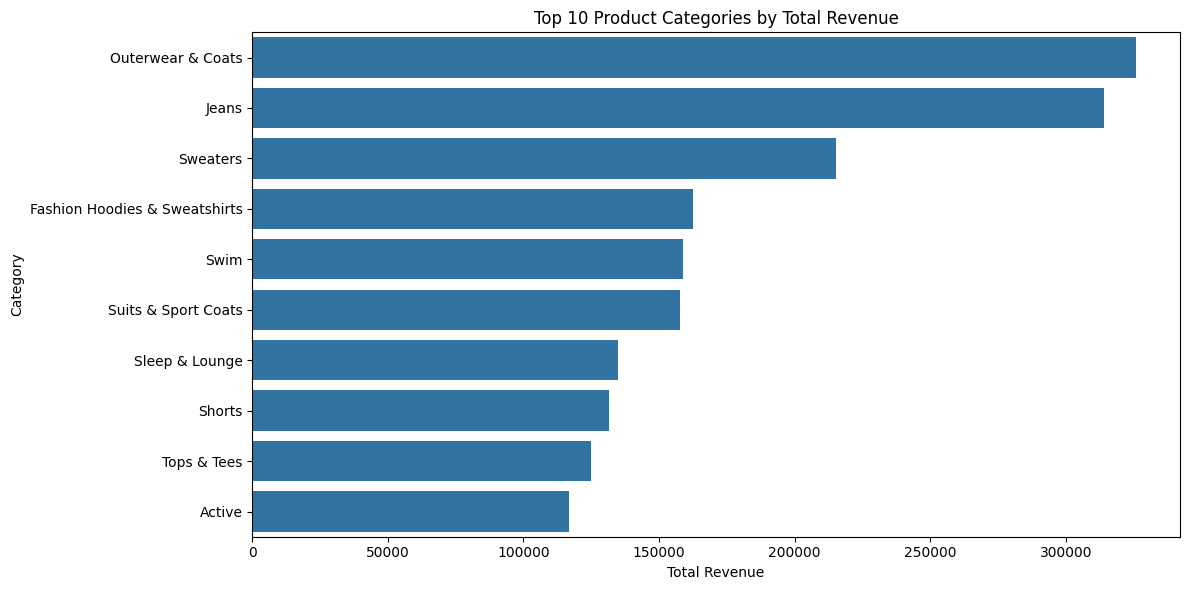

In [15]:
category_summary = (
    df.groupby("category", as_index=False)
      .agg(
          total_revenue=("revenue", "sum"),
          total_orders=("total_orders", "sum"),
          items_sold=("items_sold", "sum")
      )
      .sort_values("total_revenue", ascending=False)
)

top_categories = category_summary.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_categories,
    x="total_revenue",
    y="category"
)

plt.title("Top 10 Product Categories by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [16]:
category_summary["revenue_share_pct"] = (
    category_summary["total_revenue"]
    / category_summary["total_revenue"].sum()
    * 100
)

category_summary["revenue_per_order"] = (
    category_summary["total_revenue"]
    / category_summary["total_orders"]
)

display(
    category_summary[
        [
            "category",
            "total_revenue",
            "revenue_share_pct",
            "total_orders",
            "revenue_per_order"
        ]
    ].head(10)
)

,category,total_revenue,revenue_share_pct,total_orders,revenue_per_order
11,Outerwear & Coats,325754.89,12.104912,2178,149.566065
7,Jeans,314198.92,11.675497,3077,102.112096
22,Sweaters,215078.63,7.992230,2739,78.524509
5,Fashion Hoodies & Sweatshirts,162661.20,6.044421,2896,56.167541
23,Swim,158700.95,5.897259,2628,60.388489
21,Suits & Sport Coats,157760.57,5.862315,1199,131.576789
17,Sleep & Lounge,135007.00,5.016802,2691,50.169825
15,Shorts,131440.83,4.884285,2715,48.412829
24,Tops & Tees,125036.37,4.646298,2903,43.071433
1,Active,116730.41,4.337652,2266,51.513861


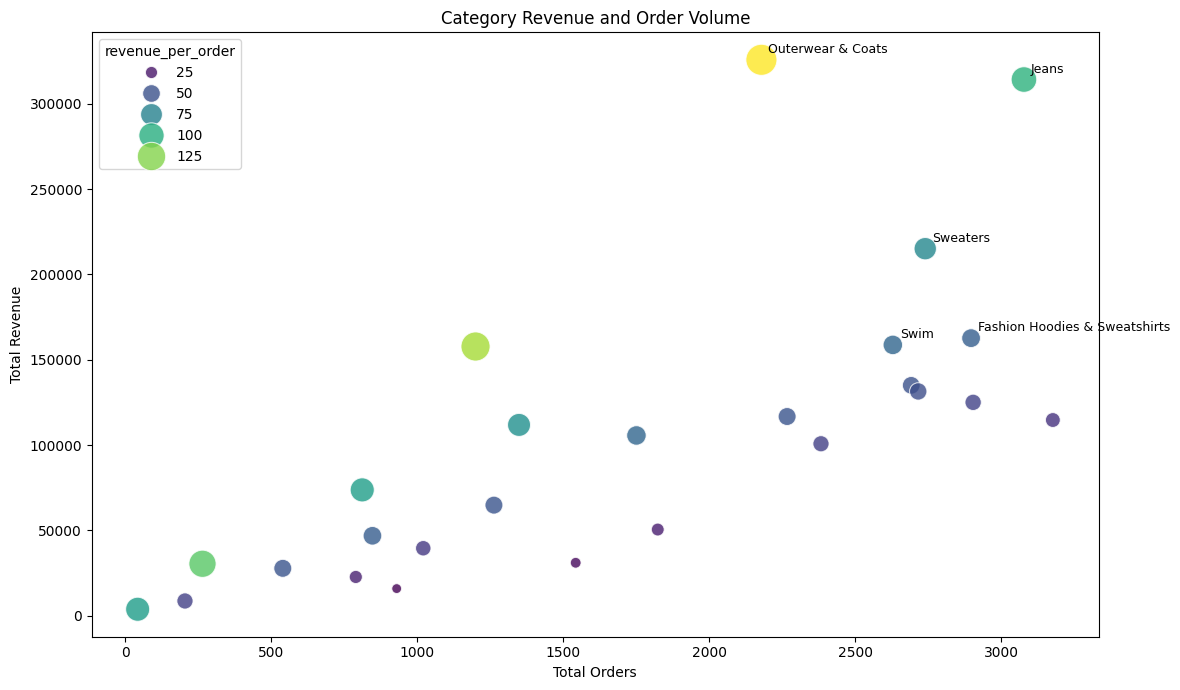

In [17]:
 plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=category_summary,
    x="total_orders",
    y="total_revenue",
    size="revenue_per_order",
    hue="revenue_per_order",
    palette="viridis",
    sizes=(50, 500),
    alpha=0.8
)

for _, row in category_summary.nlargest(5, "total_revenue").iterrows():
    plt.annotate(
        row["category"],
        (row["total_orders"], row["total_revenue"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Category Revenue and Order Volume")
plt.xlabel("Total Orders")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

In [18]:
kpis = {
    "Total Revenue": df["revenue"].sum(),
    "Total Orders": df["total_orders"].sum(),
    "Items Sold": df["items_sold"].sum(),
    "Revenue per Order": df["revenue"].sum() / df["total_orders"].sum(),
    "Top Revenue Category": category_summary.iloc[0]["category"]
}

kpi_summary = pd.DataFrame(
    list(kpis.items()),
    columns=["Metric", "Value"]
)

display(kpi_summary)

,Metric,Value
0,Total Revenue,2691096.65
1,Total Orders,44019
2,Items Sold,45404
3,Revenue per Order,61.134888
4,Top Revenue Category,Outerwear & Coats


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [19]:
monthly_sales.to_csv("monthly_sales_summary.csv", index=False)
category_summary.to_csv("category_summary.csv", index=False)
kpi_summary.to_csv("kpi_summary.csv", index=False)

print("Analysis files created successfully.")

Analysis files created successfully.
